![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/05/logo-upv-horizontal.png)
![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/06/logos-perte-chip-1024x119.png)


# Laboratory 2.0. Coupler Design

## 0. Imports 

### 0.1. General libraries

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import tidy3d as td
import gplugins.tidy3d as gt

nm = 1e-3
wavelength = np.linspace(1500, 1600) * nm
f = td.C_0 / wavelength


### 0.2. Functions by us

In [2]:
from upvfab_design_tools import MMI_EME, DC_EME

In [3]:
nitride_complex = td.material_library["Si3N4"]["Luke2015PMLStable"].eps_model(f)
nitride_index, nitride_k = td.Medium.eps_complex_to_nk(nitride_complex)
box_complex = td.material_library["SiO2"]["Horiba"].eps_model(f)
box_index, box_k = td.Medium.eps_complex_to_nk(box_complex)

## LO.1. Directional coupler length and coupling coefficient

The total power transferred to the output is modeled using the coupling coefficient (K). This coefficient depends on the relationship between the physical length of the coupling region and the beating length:

<img src="k.png" alt="Coupling Coefficient Equation" width="400">

Simulate a directional coupler that implements two deep waveguide cores of 1.2 microns width and with a gap of 600 nm between them. 
- Plot the transfer function: K vs L/Lpi
- Comment the results: distance needed for a complete energy transfer between waveguides, distance needed for splitting power in half.. 

c:\Users\david\Desktop\PIC-CHERTE\DISEÑO\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
c:\Users\david\Desktop\PIC-CHERTE\DISEÑO\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


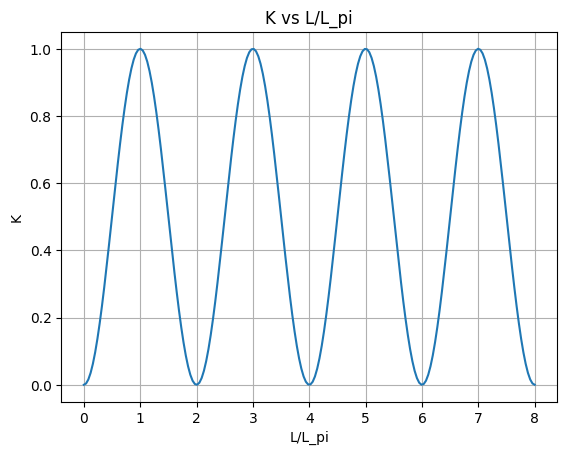

In [4]:
m = DC_EME() # Here you instantiate a Directional Coupler to be simulated with the Eigen-mode expansion (EME) algorithm.
m.DC_wg_gap = 0.6 # Gap between waveguides
m.DC_wg_width = 1.2 # Width of the waveguides core
m.DC_N_waveguides = 2

# 1) Compute de DC modes - Only execute whenever a geometrical parameter is changed. Takes time to find the modes. 
m.find_all_modes()

L_pi=m.get_L_pi()

L=np.linspace(0,8*L_pi,200)
K=np.sin(np.pi/2*(L/L_pi))**2

plt.figure()
plt.plot(L/L_pi, K)
plt.xlabel("L/L_pi")
plt.ylabel("K")
plt.title("K vs L/L_pi")
plt.grid(True)
plt.show()

## LO.2. 2x2 Directional Coupler

Here, you will use some functions provided by us (check **0. Imports** for more details) to simulate the propagation in a 2x2 directional coupler. Please read all the comments in the following code carefully and **make changes only to the lines marked with the #Student tag**

In [6]:
L_pi_values = []
gap_values = np.arange(0.6, 1.6 + 0.001, 0.1)

for i in gap_values:
# Simulation flow for Directional Couplers
# Define your geometrical parameters here
    wg_gap = i # Student. Gap between waveguides
    wg_width = 1.2 # Student. Core waveguides width

    d = wg_width + wg_gap
    wg_N = 2

    m = DC_EME() # Here you instantiate a Directional Coupler to be simulated with the Eigen-mode expansion (EME) algorithm.
    m.MMI_num_modes = 12 # Number of modes to be calculated. Here, the higher, the better since we are going to calculate
                    # the propagation based on the mode decomposition. 
    m.DC_wg_gap = wg_gap # Gap between waveguides
    m.DC_wg_width = wg_width # Width of the waveguides core
    m.DC_N_waveguides = wg_N

    # 1) Compute de DC modes - Only execute whenever a geometrical parameter is changed. Takes time to find the modes. 
    m.find_all_modes()

    # 2) Get the L_pi 
    L_pi = m.get_L_pi()
    L_pi_values.append(L_pi)
# Summary table
print("\n===== Sweep Results =====")
print(" Gap (µm)    L_pi (µm)")
for g, L in zip(gap_values, L_pi_values):
    print(f"  {g:5.2f}      {L:8.3f}")

c:\Users\david\Desktop\PIC-CHERTE\DISEÑO\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
c:\Users\david\Desktop\PIC-CHERTE\DISEÑO\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
c:\Users\david\Desktop\PIC-CHERTE\DISEÑO\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
c:\Users\david\Desktop\PIC-CHERTE\DISEÑO\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
c:\Users\david\Desktop\PIC-C


===== Sweep Results =====
 Gap (µm)    L_pi (µm)
   0.60        94.027
   0.70       128.066
   0.80       173.964
   0.90       235.774
   1.00       318.884
   1.10       430.548
   1.20       580.427
   1.30       781.390
   1.40      1050.479
   1.50      1410.684
   1.60      1892.467


c:\Users\david\Desktop\PIC-CHERTE\DISEÑO\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


c:\Users\david\Desktop\PIC-CHERTE\DISEÑO\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
c:\Users\david\Desktop\PIC-CHERTE\DISEÑO\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/1002 [00:00<?, ?it/s]

------- Pameters -------
MMI length 50.1099
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.8983
Total OUT power: 0.8860
Excess loss [dB] =  0.5256
------------------------
Power over OUTs:  ['0.0015', '0.8845']
Ratio over OUTs ['0.0017', '0.9983']


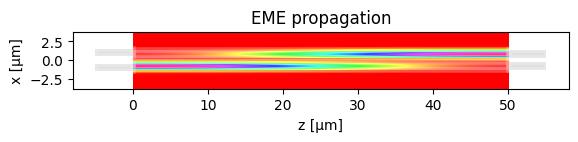

In [7]:
wg_gap = .4 # Student. Gap between waveguides
wg_width = 1.2 # Student. Core waveguides width

d = wg_width + wg_gap
wg_N = 2

m = DC_EME() # Here you instantiate a Directional Coupler to be simulated with the Eigen-mode expansion (EME) algorithm.
m.MMI_num_modes = 12 # Number of modes to be calculated. Here, the higher, the better since we are going to calculate
                    # the propagation based on the mode decomposition. 
m.DC_wg_gap = wg_gap # Gap between waveguides
m.DC_wg_width = wg_width # Width of the waveguides core
m.DC_N_waveguides = wg_N

# 1) Compute de DC modes - Only execute whenever a geometrical parameter is changed. Takes time to find the modes. 
m.find_all_modes()

# 2) Get the L_pi 
L_pi = m.get_L_pi()
# IMPORTANT!!! 
# # If you DON'T change any geometrical parameter
# (waveguide widths or gap) you can skip last cell. 
# YOU CAN RUN the lines below as many times as you wish
# (SAVES TIME)

# 3) Configure DC
# DC I/O number
m.n_IN = 2
m.n_OUT = 2

m.L_MMI = L_pi # Since we use the same library for propagation simulations of MMI and DC 
                    # some variables might be identified as "MMI". Sorry about that (: 
                    # Might change in the future 

# 4) Run propagation - get power transfer and plot propagation
m.propagation()

Text(0.5, 1.0, 'Losses dependence with gaps')

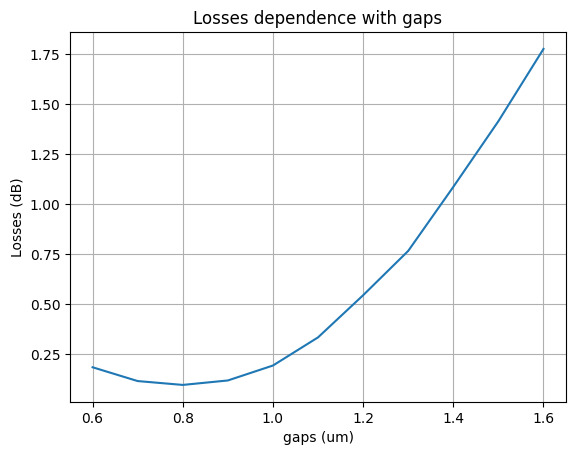

In [8]:
gaps = np.array([0.6,0.7,0.8,.9,1,1.1,1.2,1.3,1.4,1.5,1.6])
losses = np.array([0.1851,0.1161,0.0968,0.1191,0.1938,0.3345,0.5452,0.7669,1.0870,1.4155,1.7769])
ratio = np.array([0.9987,0.9989,0.9990,0.9992,0.9994,0.9995,0.9996,0.9997,0.9997,0.9997,0.9999])

plt.plot(gaps,losses)
plt.grid()
plt.xlabel('gaps (um)')
plt.ylabel('Losses (dB)')
plt.title('Losses dependence with gaps')

Text(0.5, 1.0, 'Ratio dependence with gaps')

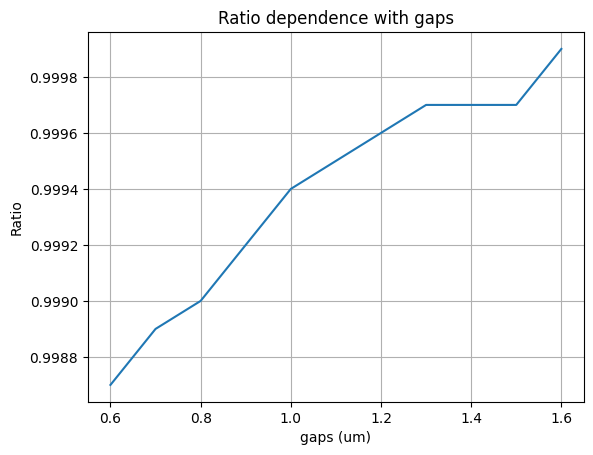

In [9]:
plt.plot(gaps,ratio)
plt.grid()
plt.xlabel('gaps (um)')
plt.ylabel('Ratio')
plt.title('Ratio dependence with gaps')

Si L=L_pi, a una de las salidas no llega nada y toda la potencia llega al otro puerto. Si L=L_pi/2 la potencia idealmente se divide 50/50 en ambos puertos.

## LO.3. Parallel uncoupled waveguides

In [10]:
# HINT. Calculate manually the L_pi you may need to achieve K=0.1
# Then you can sweep the gap and calculate the L_pi until reaching 
# the desired value. 
wg_width = 1 # Student. Core waveguides width
L = 10000
Lpi = []

gaps = np.arange(3, 4 + 0.1, 0.1)  # Sweep
K = [] 

for wg_gap in gaps:

    m = DC_EME()
    m.MMI_num_modes = 12
    m.DC_wg_gap = wg_gap
    m.DC_wg_width = wg_width
    m.DC_N_waveguides = wg_N

    # 1) Calcular modos
    m.find_all_modes()

    # 2) Obtener L_pi
    L_pi = m.get_L_pi()
    Lpi.append(L_pi)  # <-- Guardamos L_pi en el array

    # 3) Calcular K
    k_val = np.sin(np.pi/2 * (L / L_pi))**2
    K.append(k_val)

# Convertimos a arrays de numpy
K = np.array(K)
Lpi = np.array(Lpi)

print("Gaps:", gaps)
print("Lpi:", Lpi)
print("K:", K)

c:\Users\david\Desktop\PIC-CHERTE\DISEÑO\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
c:\Users\david\Desktop\PIC-CHERTE\DISEÑO\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
c:\Users\david\Desktop\PIC-CHERTE\DISEÑO\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
c:\Users\david\Desktop\PIC-CHERTE\DISEÑO\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
c:\Users\david\Desktop\PIC-C

Gaps: [3.  3.1 3.2 3.3 3.4 3.5 3.6 3.7 3.8 3.9 4. ]
Lpi: [  39758.25318933  -51693.67046437  -67159.1580228   -87180.23676486
  110094.9173917  -145655.90525357  183913.32453355 -243750.58819893
  319326.87201157 -414788.06832902 -533249.74582318]
K: [0.14813905 0.08952757 0.05371497 0.03211433 0.02021884 0.01158509
 0.00727708 0.00414713 0.00241779 0.00143344 0.00086747]


c:\Users\david\Desktop\PIC-CHERTE\DISEÑO\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


Text(0.5, 1.0, 'K vs Gap')

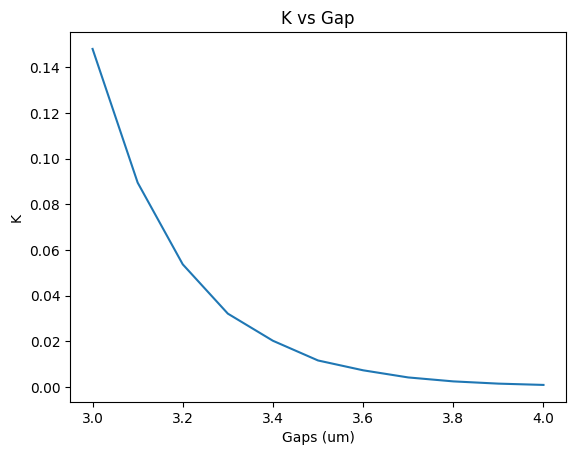

In [11]:
plt.plot(gaps,K)
plt.xlabel('Gaps (um)')
plt.ylabel('K')
plt.title('K vs Gap')

## LO.4. 2x2 Multimode Interference Coupler

### LO.4.1 Propagation Simulation

For the multimode interference (MMI) couplers we must rely on the design tables shown on the theoretical session: 

<img src="mmi.png" alt="Design tables for MMI couplers" width="600">

Here, you will use some functions provided by us (check **0. Imports** for more details) to simulate the propagation in a 2x2 directional coupler. Please read all the comments in the following code carefully and **make changes only to the lines marked with the #Student tag**

In [12]:
# Simulation flow for MMI Couplers
# Define your geometrical parameters here
mmi_Width = 6.6 # Student. Body width

m = MMI_EME() # Here you instantiate a MMI to be simulated with the Eigen-mode expansion (EME) algorithm.
m.MMI_width = mmi_Width
m.MMI_num_modes = 20 # Number of modes to be calculated. Here, the higher, the better since we are going to calculate
                    # the propagation based on the mode decomposition. 

# 1) Compute de MMI body modes - Only execute whenever a geometrical parameter is changed. Takes time to find the modes. 
m.find_all_modes()

# 2) Get the L_pi 
L_pi = m.get_L_pi()
print("L_pi = ", L_pi, " µm")

c:\Users\david\Desktop\PIC-CHERTE\DISEÑO\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  69.03598607256414  µm


c:\Users\david\Desktop\PIC-CHERTE\DISEÑO\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/690 [00:00<?, ?it/s]

------- Pameters -------
MMI length 34.5180
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9604
Total OUT power: 0.9075
Excess loss [dB] =  0.4217
------------------------
Power over OUTs:  ['0.4675', '0.4399']
Ratio over OUTs ['0.5152', '0.4848']


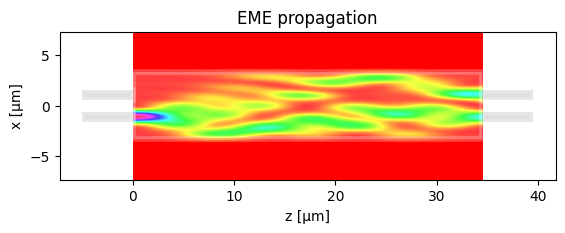

In [13]:
# IMPORTANT!!! 
# # If you DON'T change neither the MMI width 
# nor input/output waveguide widths
# YOU CAN RUN the lines below as many times as you wish
# (SAVES TIME)

# 3) Configure MMI
# # MMI I/O number (check class slides for type of MMI)
m.n_IN =  2 # STUDENT
m.n_OUT = 2 # STUDENT

# MMI I/O waveguide positions (check class slides for type of MMI)
m.IN_WVG_positions = mmi_Width*np.array([-1/6,1/6]) # STUDENT
m.OUT_WVG_positions = mmi_Width*np.array([-1/6,1/6]) # STUDENT

# MMI length (check class slides for type of MMI)
m.L_MMI = L_pi/2 # STUDENT

# Run propagation
m.propagation()

### LO.4.2. 2x2 Multimode Interference Coupler - Optimization

  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/680 [00:00<?, ?it/s]

------- Pameters -------
MMI length 34.5180
MMI length increment -0.5000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9524
Total OUT power: 0.9032
Excess loss [dB] =  0.4423
------------------------
Power over OUTs:  ['0.4560', '0.4472']
Ratio over OUTs ['0.5049', '0.4951']


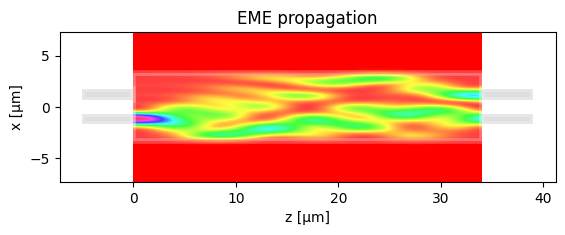

In [14]:
dy = 0.1
# MMI I/O waveguide positions (check class slides for type of MMI)
m.IN_WVG_positions = mmi_Width*np.array([-1/6,1/6]) + np.array([-dy,dy]) # STUDENT
m.OUT_WVG_positions = mmi_Width*np.array([-1/6,1/6]) + np.array([-dy,dy]) # STUDENT

# MMI length (check class slides for type of MMI)
m.dL_MMI = -0.5 # STUDENT

# Run propagation
m.propagation()

### LO.4.3 2x2 Multimode Interference Coupler – Optimization (II)

c:\Users\david\Desktop\PIC-CHERTE\DISEÑO\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
c:\Users\david\Desktop\PIC-CHERTE\DISEÑO\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/680 [00:00<?, ?it/s]

------- Pameters -------
MMI length 34.5180
MMI length increment -0.5000
IO wg width 1.0000
IO wg width increment 1.3000
------------------------
Total power IN coupled 0.9995
Total OUT power: 0.9963
Excess loss [dB] =  0.0159
------------------------
Power over OUTs:  ['0.5099', '0.4864']
Ratio over OUTs ['0.5118', '0.4882']


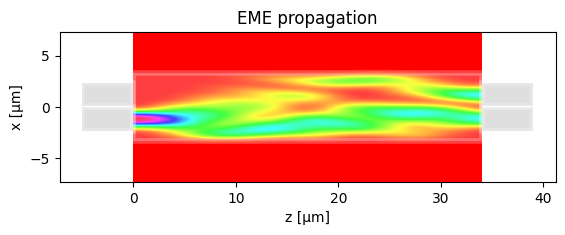

In [15]:
# Design flow for MMI

m = MMI_EME()
m.MMI_width = 6.6   # MMI width
m.wg_width_dw = 1.3 # STUDENT

# 1) Compute de MMI modes
m.find_all_modes()

# 2) Get the L_pi
L_pi = m.get_L_pi()

# 3) Configure MMI
# # MMI I/O number (check class slides for type of MMI)
m.n_IN = 2 # STUDENT
m.n_OUT = 2 # STUDENT

dy = 0.1
# MMI I/O waveguide positions (check class slides for type of MMI)
m.IN_WVG_positions = mmi_Width*np.array([-1/6,1/6]) + np.array([-dy,dy]) # STUDENT
m.OUT_WVG_positions = mmi_Width*np.array([-1/6,1/6]) + np.array([-dy,dy]) # STUDENT

# MMI length (check class slides for type of MMI)
m.L_MMI = L_pi/2  # STUDENT
m.dL_MMI = -.5 # STUDENT

# Run propagation
m.propagation()

## LO.5. 1x4 1x4 Multimode Interference Coupler 

Repeat the design procedure explained for the 2x2 Coupler to design a 1x4 MMI Coupler. Consider: 
- Select a suitable MMI body width, taking into account that you now must allocate 4 waveguides at the output. 
- Minimize the losses and output imbalance for the MMI coupler. 

c:\Users\david\Desktop\PIC-CHERTE\DISEÑO\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
c:\Users\david\Desktop\PIC-CHERTE\DISEÑO\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/13 [00:00<?, ?it/s]

  0%|          | 0/822 [00:00<?, ?it/s]

------- Pameters -------
MMI length 41.0886
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9612
Total OUT power: 0.8578
Excess loss [dB] =  0.6661
------------------------
Power over OUTs:  ['0.2144', '0.2146', '0.2146', '0.2143']
Ratio over OUTs ['0.2499', '0.2501', '0.2501', '0.2498']


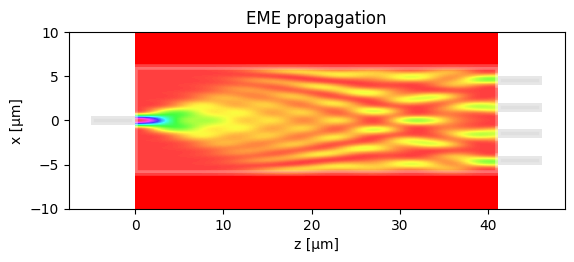

In [20]:
# Simulation flow for MMI Couplers
# Define your geometrical parameters here
mmi_Width = 12 # Student. Body width

m = MMI_EME() # Here you instantiate a MMI to be simulated with the Eigen-mode expansion (EME) algorithm.
m.MMI_width = mmi_Width
m.MMI_num_modes = 40 # Number of modes to be calculated. Here, the higher, the better since we are going to calculate
                    # the propagation based on the mode decomposition. 

# 1) Compute de MMI body modes - Only execute whenever a geometrical parameter is changed. Takes time to find the modes. 
m.find_all_modes()

# 2) Get the L_pi 
L_pi = m.get_L_pi()

# 3) Configure MMI
# # MMI I/O number (check class slides for type of MMI)
m.n_IN =  1 # STUDENT
m.n_OUT = 4 # STUDENT

# MMI I/O waveguide positions (check class slides for type of MMI)
m.IN_WVG_positions = np.array([0]) # STUDENT
m.OUT_WVG_positions = mmi_Width*np.array([-3/8, -1/8, 1/8, 3/8]) # STUDENT

# MMI length (check class slides for type of MMI)
m.L_MMI = 3*L_pi/16 # STUDENT

# Run propagation
m.propagation()

  0%|          | 0/13 [00:00<?, ?it/s]

  0%|          | 0/798 [00:00<?, ?it/s]

------- Pameters -------
MMI length 41.0886
MMI length increment -1.2000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9599
Total OUT power: 0.9012
Excess loss [dB] =  0.4520
------------------------
Power over OUTs:  ['0.2351', '0.2261', '0.2143', '0.2257']
Ratio over OUTs ['0.2609', '0.2509', '0.2378', '0.2505']


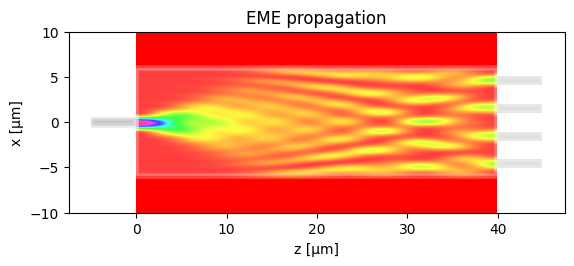

In [46]:
dy = 0.1
# MMI I/O waveguide positions (check class slides for type of MMI)
m.IN_WVG_positions = np.array([0]) + np.array([-dy,dy]) # STUDENT
m.OUT_WVG_positions = mmi_Width*np.array([-3/8, -1/8, 1/8, 3/8]) + np.array([-dy, -dy/2 ,dy/2, dy]) # STUDENT

# MMI length (check class slides for type of MMI)
m.dL_MMI = -1.2 # STUDENT

# Run propagation
m.propagation()

c:\Users\david\Desktop\PIC-CHERTE\DISEÑO\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
c:\Users\david\Desktop\PIC-CHERTE\DISEÑO\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/12 [00:00<?, ?it/s]

  0%|          | 0/798 [00:00<?, ?it/s]

------- Pameters -------
MMI length 41.0886
MMI length increment -1.2000
IO wg width 1.0000
IO wg width increment 2.0000
------------------------
Total power IN coupled 0.9982
Total OUT power: 0.9997
Excess loss [dB] =  0.0015
------------------------
Power over OUTs:  ['0.2453', '0.2688', '0.2601', '0.2254']
Ratio over OUTs ['0.2454', '0.2689', '0.2602', '0.2255']


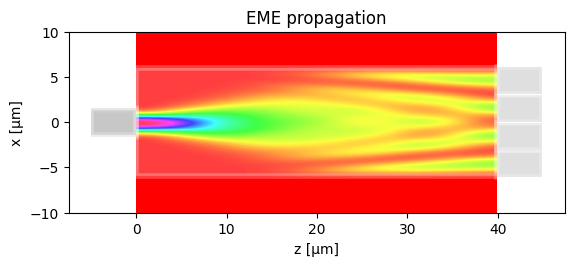

In [52]:
# Design flow for MMI
m = MMI_EME()
m.MMI_width = 12   # MMI width
m.wg_width_dw = 2 # STUDENT

# 1) Compute de MMI modes
m.find_all_modes()

# 2) Get the L_pi
L_pi = m.get_L_pi()

# 3) Configure MMI
# # MMI I/O number (check class slides for type of MMI)
m.n_IN = 1 # STUDENT
m.n_OUT = 4 # STUDENT

dy = 0.1
# MMI I/O waveguide positions (check class slides for type of MMI)
m.IN_WVG_positions = np.array([0]) + np.array([-dy,dy]) # STUDENT
m.OUT_WVG_positions = mmi_Width*np.array([-3/8, -1/8, 1/8, 3/8]) + np.array([-dy, -dy/2 ,dy/2, dy]) # STUDENT

# MMI length (check class slides for type of MMI)
m.L_MMI = 3*L_pi/16  # STUDENT
m.dL_MMI = -1.2 # STUDENT

# Run propagation
m.propagation()

## Extra - Exercises

### E1. Directional coupler wavelength dependence

#### Deep case

In [108]:
gap_to_simulate = 600 * nm # STUDENT. You can manually change the gap
                            # or you can sweep the parameter using a Python for loop. 
wavelength = np.linspace(1.5,1.7,80)

Lpi_TE = []
Lpi_TM= []

for wl in wavelength:

    dc = gt.modes.WaveguideCoupler(
        wavelength=wl,
        core_width=(1.0, 1.0),
        gap=gap_to_simulate,
        slab_thickness=0 * nm,
        core_material='sin',
        clad_material='sio2',
        core_thickness=300 * nm,
        num_modes=4,
        cache_path='.cache/',
        precision='double',
        max_grid_scaling=1.5,
        grid_resolution=20
    )

    neff = dc.n_eff
    print(dc.fraction_te)



2026-03-07 13:32:36.524 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\WaveguideCoupler_fc2c62c75e0d5f6e.npz.
[0.99310671 0.99329003 0.01004049 0.01294311]
2026-03-07 13:32:36.526 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\WaveguideCoupler_533857b17e3803dd.npz.
[0.99309733 0.99327848 0.01001658 0.01292651]
2026-03-07 13:32:36.528 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\WaveguideCoupler_56d28df39ab38b66.npz.
[0.99281842 0.99283791 0.0106458  0.01374002]
2026-03-07 13:32:36.530 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\WaveguideCoupler_41510a84fc8c6d72.npz.
[0.99303101 0.99318275 0.01033353 0.01337952]
2026-03-07 13:32:36.531 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\WaveguideCoupler_90e8b7d2eb2f8bc0.npz.
[0.99328809 0.99347365 0.0102562  0.01326708]
2026-03-07 13:32:36.532 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\WaveguideCoupler_

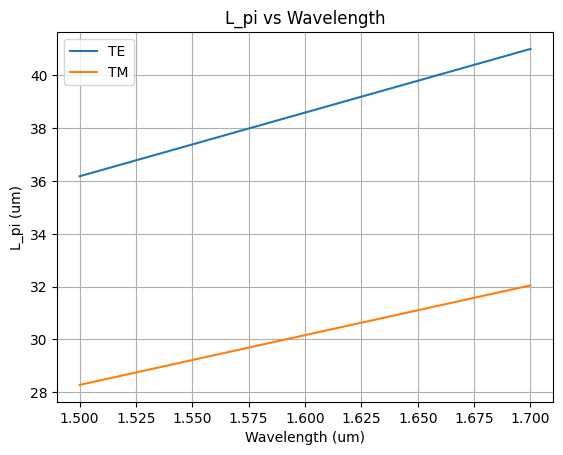

In [109]:
for wl in wavelength:
    Lpi_TE.append(wl/(2*(neff[0]-neff[1])))
    Lpi_TM.append(wl/(2*(neff[2]-neff[3])))

# STUDENT. Plot goes here
# Convert to arrays
Lpi_TE = np.array(Lpi_TE)
Lpi_TM = np.array(Lpi_TM)

# Plot
plt.figure()
plt.plot(wavelength, Lpi_TE, label='TE')
plt.plot(wavelength, Lpi_TM, label='TM')

plt.xlabel('Wavelength (um)')
plt.ylabel('L_pi (um)')
plt.title('L_pi vs Wavelength')
plt.legend()
plt.grid()

plt.show()

#### Shallow case

2026-03-07 13:54:15.794 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\WaveguideCoupler_29275665d8177d38.npz.
2026-03-07 13:54:15.796 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\WaveguideCoupler_dbc0af4e67739848.npz.
2026-03-07 13:54:15.799 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\WaveguideCoupler_45c22966eeb98392.npz.
2026-03-07 13:54:15.801 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\WaveguideCoupler_7affc0dab894b8a5.npz.
2026-03-07 13:54:15.802 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\WaveguideCoupler_80752ab22ec2b98a.npz.
2026-03-07 13:54:15.804 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\WaveguideCoupler_79818c67defc66df.npz.
2026-03-07 13:54:15.805 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\WaveguideCoupler_19a1da250e1af5a5.npz.
2026-03-07 13:54:15.807 | INFO     | gplugins.tidy3d.modes:_data:266 - load 

c:\Users\david\Desktop\PIC-CHERTE\DISEÑO\pic-upv-lab2\.venv\Lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\david\Desktop\PIC-CHERTE\DISEÑO\pic-upv-lab2\.venv\Lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


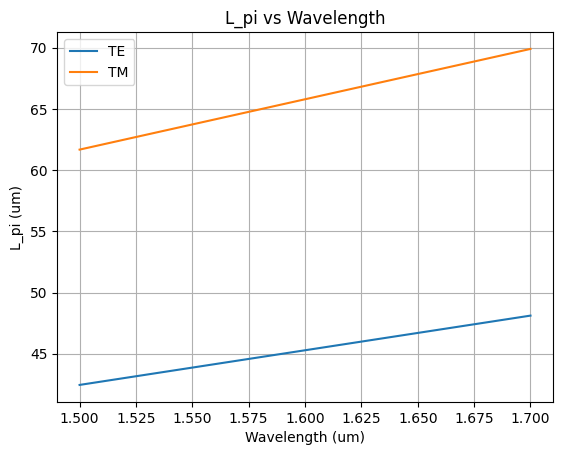

[np.complex128(1.6248672556218713+0.0001033784949909237j), np.complex128(1.6072004255639063+0.00010096611813360196j), np.complex128(1.5266055924361064+0.0001562361663100802j), np.complex128(1.6507417840857468+9.066382785554782e-05j), np.complex128(1.633018086437903+8.854669917204875e-05j), np.complex128(1.5638557060762281+0.0001346369032626568j), np.complex128(1.5571147681277622+0.00013699465071073512j), np.complex128(1.6358010401685013+9.780843571972644e-05j), np.complex128(1.6178635604573437+9.564449978176268e-05j), np.complex128(1.5468183630487848+0.00014489133661801018j), np.complex128(1.5395407404166912+0.00014797227029845851j), np.complex128(1.6498780090021452+9.078417391776722e-05j), np.complex128(1.631954235426326+8.872451240974696e-05j), np.complex128(1.5632156023909356+0.00013458188001014854j), np.complex128(1.5564881155525696+0.00013679049412576726j), np.complex128(1.6351824925663252+9.760549839104574e-05j), np.complex128(1.6171514302669678+9.540254965929985e-05j), np.comple

In [138]:
gap_to_simulate = 600 * nm # STUDENT. You can manually change the gap
                            # or you can sweep the parameter using a Python for loop. 
wavelength = np.linspace(1.5,1.7,80)

Lpi_TE = []
Lpi_TM= []

TE = []
TM = []

for wl in wavelength:

    dc = gt.modes.WaveguideCoupler(
        wavelength=wl,
        core_width=(1.0, 1.0),
        gap=gap_to_simulate,
        slab_thickness=150 * nm,
        core_material='sin',
        clad_material='sio2',
        core_thickness=300 * nm,
        num_modes=6,
        cache_path='.cache/',
        precision='double',
        max_grid_scaling=1.5,
        grid_resolution=20
    )

    neff = dc.n_eff
    TE_frac = dc.fraction_te
    # Recorrer cada modo
    for idx, frac in enumerate(TE_frac):
        if frac > 0.9:
            TE.append(neff[idx])
        else:
            TM.append(neff[idx])
           
    Lpi_TE.append(wl/(2*(TE[0]-TE[1])))
    Lpi_TM.append(wl/(2*(TM[0]-TM[1])))

# STUDENT. Plot goes here
# Convert to arrays
Lpi_TE = np.array(Lpi_TE)
Lpi_TM = np.array(Lpi_TM)

# Plot
plt.figure()
plt.plot(wavelength, Lpi_TE, label='TE')
plt.plot(wavelength, Lpi_TM, label='TM')

plt.xlabel('Wavelength (um)')
plt.ylabel('L_pi (um)')
plt.title('L_pi vs Wavelength')
plt.legend()
plt.grid()

plt.show()
print(TE)

### E2. Directional coupler gap dependence. CORREGIR

#### Deep case

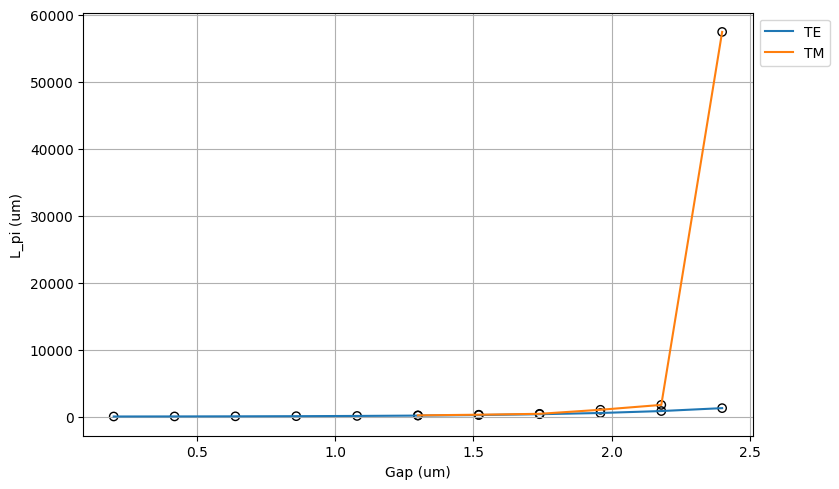

In [143]:
gap_to_simulate = 600 * nm # STUDENT. You can manually change the gap
                            # or you can sweep the parameter using a Python for loop. 
wavelength = 1.55
gap = np.linspace(0.2,2.4,11) 

Lpi_TE = []
Lpi_TM= []

TE = []
TM = []

for i in gap:
    deep_dcoupler_cs = gt.modes.WaveguideCoupler(
        wavelength=wavelength, # Wavelength to simulate - Must be a vector
        core_width=(1.0, 1.0), # Waveguide width
        gap=i,
        slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
        core_material='sin', #  Material of the waveguide
        clad_material='sio2', # Surrounding material
        core_thickness=300 * nm, # Waveguide height 
        num_modes=4, # Number of modes to find
        cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
        precision='double',
        max_grid_scaling=1.5, # Parameters of the grid
        grid_resolution=20 # Parameters of the grid
    )   
    
    neff = dc.n_eff
    TE_frac = dc.fraction_te
    # Recorrer cada modo
    for idx, frac in enumerate(TE_frac):
        if frac > 0.9:
            TE.append(neff[idx])
        else:
            TM.append(neff[idx])

    Lpi_TE.append(wavelength/(2*(TE[0]-TE[1])))
    Lpi_TM.append(wavelength/(2*(TM[0]-TM[1])))

# STUDENT. Plot goes here
# Convert to arrays
Lpi_TE = np.array(Lpi_TE)
Lpi_TM = np.array(Lpi_TM)

plt.figure(figsize=(10, 5))
plt.scatter(gap, L_pi_TE,edgecolors='k',facecolors='none',label = '__nolegend__')
plt.plot(gap, L_pi_TE,label='TE')
plt.scatter(gap, L_pi_TM,edgecolors='k',facecolors='none',label = '__nolegend__')
plt.plot(gap, L_pi_TM,label='TM')
plt.xlabel("Gap (um)")
plt.ylabel("L_pi (um)")
plt.grid()
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout(rect=[0, 0, 0.85, 1])

2026-03-07 13:24:54.059 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\WaveguideCoupler_19fc40f5ad5a09a8.npz.
[0.99389029 0.99323917 0.00721455 0.01609921]
2026-03-07 13:24:54.063 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\WaveguideCoupler_f7bf48518bd103a5.npz.
[0.99284265 0.99299391 0.00935288 0.01410028]
2026-03-07 13:24:54.065 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\WaveguideCoupler_05d4d59f6526ea9c.npz.
[0.99254591 0.99252573 0.01020774 0.01312436]
2026-03-07 13:24:54.066 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\WaveguideCoupler_a1a58e20b0ad8dc8.npz.
[0.99280688 0.99282392 0.01055706 0.01244888]
[0.99282278 0.99280877 0.01078947 0.01208498]
2026-03-07 13:24:54.069 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\WaveguideCoupler_3a582071184899b0.npz.
2026-03-07 13:24:54.070 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\WaveguideCoupler_

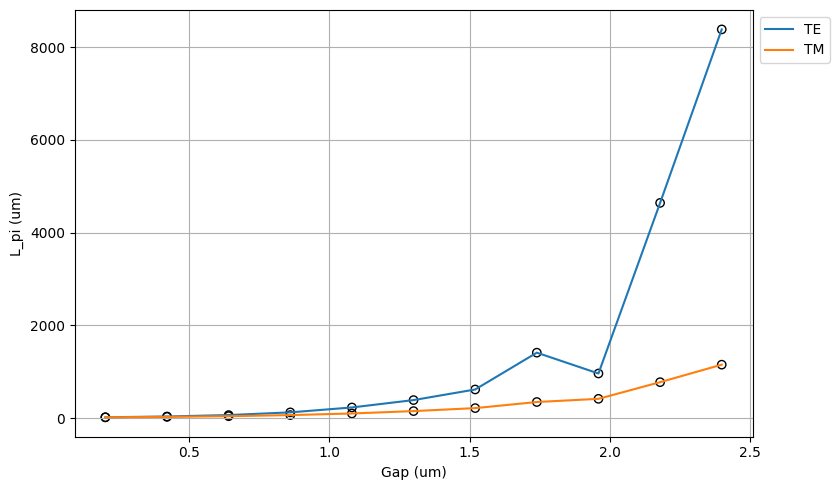

In [ ]:
wavelength = 1.55 # STUDENT code goes here
gap = np.linspace(0.2,2.4,11) 

L_pi_TE = []
L_pi_TM = []
for i in gap:
    deep_dcoupler_cs = gt.modes.WaveguideCoupler(
        wavelength=wavelength, # Wavelength to simulate - Must be a vector
        core_width=(1.0, 1.0), # Waveguide width
        gap=i,
        slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
        core_material='sin', #  Material of the waveguide
        clad_material='sio2', # Surrounding material
        core_thickness=300 * nm, # Waveguide height 
        num_modes=4, # Number of modes to find
        cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
        precision='double',
        max_grid_scaling=1.5, # Parameters of the grid
        grid_resolution=20 # Parameters of the grid
    )   

    deep_neff = deep_dcoupler_cs.n_eff
    print(deep_dcoupler_cs.fraction_te)

    
    L_pi_TE.append(wavelength / (2 * (deep_neff[0]-deep_neff[1]))) # STUDENT code here
    L_pi_TM.append(wavelength / (2 * (deep_neff[2]-deep_neff[3]))) # STUDENT code here

plt.figure(figsize=(10, 5))
plt.scatter(gap, L_pi_TE,edgecolors='k',facecolors='none',label = '__nolegend__')
plt.plot(gap, L_pi_TE,label='TE')
plt.scatter(gap, L_pi_TM,edgecolors='k',facecolors='none',label = '__nolegend__')
plt.plot(gap, L_pi_TM,label='TM')
plt.xlabel("Gap (um)")
plt.ylabel("L_pi (um)")
plt.grid()
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout(rect=[0, 0, 0.85, 1])

#### Shallow case

2026-03-07 13:40:06.131 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\WaveguideCoupler_8c8eb63846dcafc2.npz.
2026-03-07 13:40:06.132 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\WaveguideCoupler_4750b76c20c4f150.npz.
2026-03-07 13:40:06.134 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\WaveguideCoupler_64c4d66f47a5f436.npz.
2026-03-07 13:40:06.136 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\WaveguideCoupler_da79dae99ff833e8.npz.
2026-03-07 13:40:06.137 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\WaveguideCoupler_851b09b1693cd69c.npz.
2026-03-07 13:40:06.138 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\WaveguideCoupler_2bdc274ebb0d96f6.npz.
2026-03-07 13:40:06.140 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\WaveguideCoupler_bc16612d25a64c49.npz.
2026-03-07 13:40:06.142 | INFO     | gplugins.tidy3d.modes:_data:266 - load 

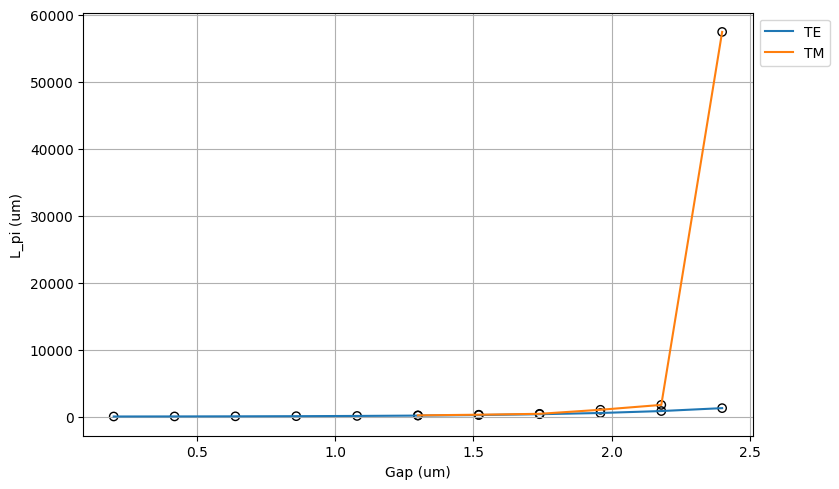

In [121]:
wavelength = 1.55 # STUDENT code goes here
gap = np.linspace(0.2,2.4,11) 

# Función para clasificar modos según fraction_te
def classify_modes_simple(fraction_te, te_thresh=0.9):
    te_modes = []
    tm_modes = []
    for i, f_te in enumerate(fraction_te):
        if f_te > te_thresh:
            te_modes.append(i)
        else:
            tm_modes.append(i)
    return te_modes, tm_modes

L_pi_TE = []
L_pi_TM = []

for i in gap:
    deep_dcoupler_cs = gt.modes.WaveguideCoupler(
        wavelength=wavelength, # Wavelength to simulate - Must be a vector
        core_width=(1.0, 1.0), # Waveguide width
        gap=i,
        slab_thickness=150 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
        core_material='sin', #  Material of the waveguide
        clad_material='sio2', # Surrounding material
        core_thickness=300 * nm, # Waveguide height 
        num_modes=4, # Number of modes to find
        cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
        precision='double',
        max_grid_scaling=1.5, # Parameters of the grid
        grid_resolution=20 # Parameters of the grid
    )   

    deep_neff = deep_dcoupler_cs.n_eff
    fraction_te = deep_dcoupler_cs.fraction_te

    # Clasificar modos
    te_modes, tm_modes = classify_modes(fraction_te)

    # Calcular L_pi usando los primeros dos modos de cada polarización
    if len(te_modes) >= 2:
        L_pi_TE.append(wavelength / (2 * abs(deep_neff[te_modes[0]] - deep_neff[te_modes[1]])))
    else:
        L_pi_TE.append(np.nan)

    if len(tm_modes) >= 2:
        L_pi_TM.append(wavelength / (2 * abs(deep_neff[tm_modes[0]] - deep_neff[tm_modes[1]])))
    else:
        L_pi_TM.append(np.nan)

plt.figure(figsize=(10, 5))
plt.scatter(gap, L_pi_TE,edgecolors='k',facecolors='none',label = '__nolegend__')
plt.plot(gap, L_pi_TE,label='TE')
plt.scatter(gap, L_pi_TM,edgecolors='k',facecolors='none',label = '__nolegend__')
plt.plot(gap, L_pi_TM,label='TM')
plt.xlabel("Gap (um)")
plt.ylabel("L_pi (um)")
plt.grid()
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout(rect=[0, 0, 0.85, 1])
print(L_pi_TM)
    

c:\Users\david\Desktop\PIC-CHERTE\DISEÑO\pic-upv-lab2\.venv\Lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)


ValueError: x and y must be the same size

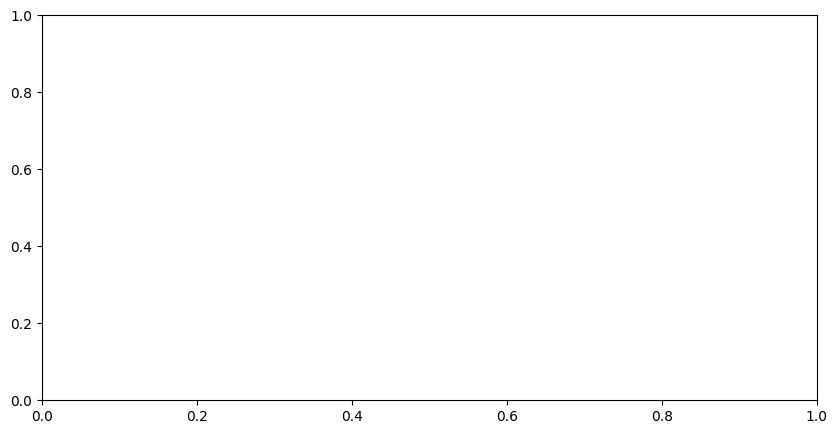

### E3. MMI coupler wavelength dependence

In [ ]:
mmi_body_w = 6.6 
lambda_c = ... # STUDENT code goes here.

mmi_body_waveguide = gt.modes.Waveguide(
    # Geometrical Parameters
    core_width=mmi_body_w, # MMI Body width
    core_thickness=300 * nm, # MMI Body height 
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguides.
    # Materials
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    wavelength=lambda_c, # Wavelength to simulate
    num_modes=15, # Targeted number of modes to find - Higher than before! It's a multimode section
    max_grid_scaling=1.5, # Parameters of the grid
    grid_resolution=20, # Parameters of the grid
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
)

d_n_eff = mmi_body_waveguide.n_eff[0].real -  mmi_body_waveguide.n_eff[1].real

L_pi = ... # STUDENT code goes here

# STUDENT plot here. 

### E4. MMI coupler body width dependence

In [ ]:
lambda_c = 1.55

mmi_body_w = 6.6 # STUDENT. You can manually change the body width
                 # or you can sweep the parameter using a Python for loop. 

mmi_body_waveguide = gt.modes.Waveguide(
    # Geometrical Parameters
    core_width=mmi_body_w, # MMI Body width
    core_thickness=300 * nm, # MMI Body height 
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguides.
    # Materials
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    wavelength=lambda_c, # Wavelength to simulate
    num_modes=15, # Targeted number of modes to find - Higher than before! It's a multimode section
    max_grid_scaling=1.5, # Parameters of the grid
    grid_resolution=20, # Parameters of the grid
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
)

d_n_eff = mmi_body_waveguide.n_eff[0].real -  mmi_body_waveguide.n_eff[1].real

L_pi = ... # STUDENT code goes here

# STUDENT plot here. 